# Social Network Ads

<img src='https://muimedya.com/wp-content/uploads/2023/11/alisveris.jpg'>

Sosyal medya reklamlarına ilişkin veri seti kullanılarak; kullanıcıların reklamlara tıklayarak ürün satın alıp almadıklarını ve bu satın alımların gerçekleşip gerçekleşmediğini tahmin eden bir classification modeli oluşturulacaktır

In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB


from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
#EDA

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
#df['Gender'].replace({'Female': 0, 'Male': 1}, inplace=True)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Gender,400.0,4.900000e-01,0.500526,0.0,0.00,0.0,1.0,1.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


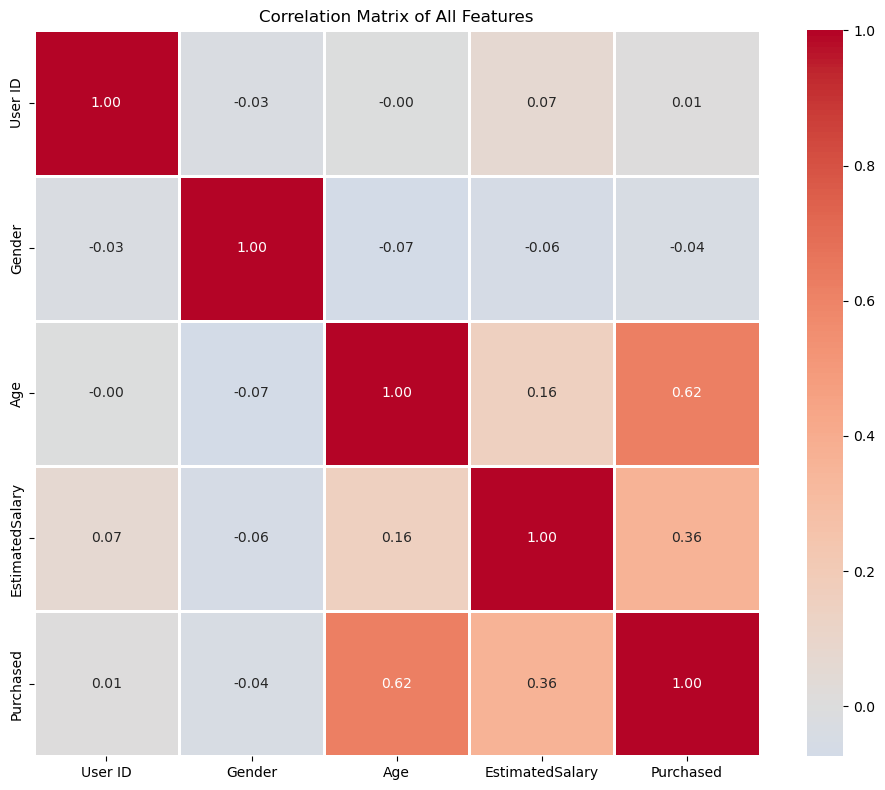

In [9]:
# Correlation heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

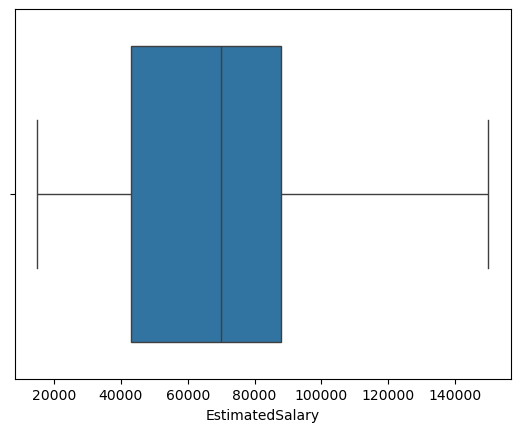

In [10]:
#Age, EstimatedSalary
sns.boxplot(x=df['EstimatedSalary']);  

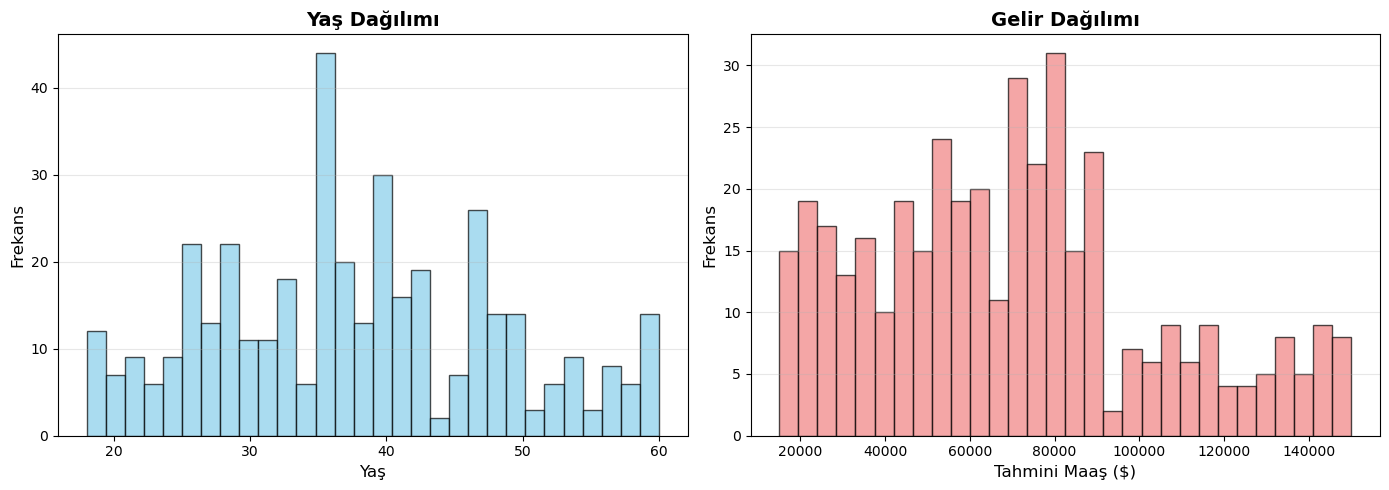

In [11]:
# Grafik 1: Yaş ve Gelir Dağılımı
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Yaş', fontsize=12)
plt.ylabel('Frekans', fontsize=12)
plt.title('Yaş Dağılımı', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['EstimatedSalary'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel('Tahmini Maaş ($)', fontsize=12)
plt.ylabel('Frekans', fontsize=12)
plt.title('Gelir Dağılımı', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
#Feature Engineering

In [15]:
df['SalaryLevel'] = pd.cut(df['EstimatedSalary'], bins=[15000, 43000, 70000, 88000, 150000], labels=[1, 2, 3, 4])

In [16]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60], labels=[1, 2, 3, 4])

In [19]:
df['IsYoungRich'] = ((df['Age'] < 30) & (df['EstimatedSalary'] > 50000)).astype(int)

In [20]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,SalaryLevel,AgeGroup,IsYoungRich
0,15624510,1,19,19000,0,1,1,0
1,15810944,1,35,20000,0,1,2,0
2,15668575,0,26,43000,0,1,1,0
3,15603246,0,27,57000,0,2,1,1
4,15804002,1,19,76000,0,3,1,1


In [21]:
x = df.drop(["User ID", "Purchased"], axis=1, errors='ignore')
y = df["Purchased"]

In [22]:
x=pd.get_dummies(x, drop_first=True)

In [24]:
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.15)

In [26]:
g=GaussianNB()
b=BernoulliNB()

In [27]:
gmodel=g.fit(x_train,y_train)

In [28]:
gtahmin=gmodel.predict(x_test)

In [29]:
bmodel=b.fit(x_train,y_train)

In [30]:
btahmin=bmodel.predict(x_test)

In [31]:
accuracy_score(y_test, gtahmin)

0.9333333333333333

In [32]:
confusion_matrix(y_test,gtahmin)

array([[38,  3],
       [ 1, 18]])

In [33]:
print(classification_report(y_test,gtahmin))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        41
           1       0.86      0.95      0.90        19

    accuracy                           0.93        60
   macro avg       0.92      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



<Axes: >

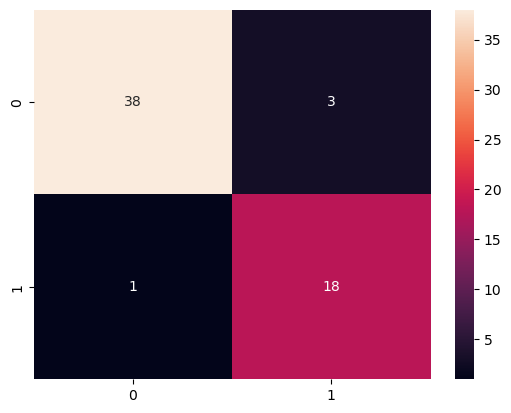

In [34]:
sns.heatmap(confusion_matrix(y_test,gtahmin), annot=True)

In [35]:
accuracy_score(y_test,btahmin)

0.9666666666666667

In [36]:
print(classification_report(y_test,btahmin))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        41
           1       0.90      1.00      0.95        19

    accuracy                           0.97        60
   macro avg       0.95      0.98      0.96        60
weighted avg       0.97      0.97      0.97        60



In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [38]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[49  3]
 [ 2 26]]
LogisticRegression()  modeli eğitiliyor!..
[[49  3]
 [ 2 26]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[46  6]
 [ 7 21]]
RandomForestClassifier()  modeli eğitiliyor!..
[[48  4]
 [ 5 23]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[48  4]
 [ 6 22]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[46  6]
 [ 8 20]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[49  3]
 [ 3 25]]
MultinomialNB()  modeli eğitiliyor!..
[[49  3]
 [12 16]]
Eğitim tamamlandı.
En başarılı model:  BernoulliNB
Confusion Matrix:
[[49  3]
 [ 2 26]]
classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        52
           1       0.90      0.93      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80

Diğer Modeller:


,Accuracy,Precision,Recall,F1
BernoulliNB,0.9375,0.9375,0.9375,0.9375
LogisticRegression,0.9375,0.9375,0.9375,0.9375
AdaBoostClassifier,0.9250,0.9250,0.9250,0.9250
RandomForestClassifier,0.8875,0.8875,0.8875,0.8875
GradientBoostingClassifier,0.8750,0.8750,0.8750,0.8750
DecisionTreeClassifier,0.8375,0.8375,0.8375,0.8375
KNeighborsClassifier,0.8250,0.8250,0.8250,0.8250
MultinomialNB,0.8125,0.8125,0.8125,0.8125


In [40]:
## Classification with Deep Learning

In [41]:
x = df.drop(["User ID", "Purchased"], axis=1, errors='ignore')
y = df["Purchased"]

In [42]:
x = pd.get_dummies(x, drop_first=True)

In [43]:
x.head()

,Gender,Age,EstimatedSalary,IsYoungRich,SalaryLevel_2,SalaryLevel_3,SalaryLevel_4,AgeGroup_2,AgeGroup_3,AgeGroup_4
0,1,19,19000,0,False,False,False,False,False,False
1,1,35,20000,0,False,False,False,True,False,False
2,0,26,43000,0,False,False,False,False,False,False
3,0,27,57000,1,True,False,False,False,False,False
4,1,19,76000,1,False,True,False,False,False,False


In [44]:
y.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = scaler.fit_transform(x)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(80, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [51]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [52]:
history=model.fit(x,y,batch_size=32, validation_split=0.20,verbose=1, epochs=20,callbacks=[early_stop])

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7125 - loss: 0.6058 - val_accuracy: 0.3625 - val_loss: 0.6791
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7344 - loss: 0.4811 - val_accuracy: 0.4750 - val_loss: 0.6284
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7812 - loss: 0.3951 - val_accuracy: 0.4875 - val_loss: 0.5913
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8094 - loss: 0.3434 - val_accuracy: 0.6750 - val_loss: 0.5725
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8750 - loss: 0.3218 - val_accuracy: 0.8500 - val_loss: 0.5750
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9000 - loss: 0.3084 - val_accuracy: 0.8625 - val_loss: 0.5664
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9062 - loss: 0.3032 - val_accuracy: 0.8750 - val_loss: 0.5387
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9031 - loss: 0.2949 - val_accuracy: 0.8750 - v

In [53]:
loss, accuracy=model.evaluate(x,y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9175 - loss: 0.2266 


In [54]:
tahmin = model.predict(x)
tahmin_classes = tahmin.argmax(axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [55]:
for i in range(100):
    print("Gerçek:", y.iloc[i], 
      "Tahmin:", tahmin_classes[i])

Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 0 Tahmin: 0
Gerçek: 1 Tahmin: 0
Gerçek: 0 Tahmin: 0


In [57]:
best_model =  BernoulliNB()
best_model.fit(x, y)

#2. Feature listesini al
x = df.drop(["User ID", "Purchased"], axis=1, errors='ignore')
x=pd.get_dummies(x, drop_first=True)

features = list(x.columns)

# 3. Modeli kaydet (joblib + pkl)
import joblib, pickle

# joblib 
joblib.dump(best_model, 'Purchased.joblib')

# bundle (model + feature)
with open('Purchased.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'features': features
    }, f)

Geliştirilen derin öğrenme tabanlı sınıflandırma modeli ile test veri seti üzerinde %91 doğruluk oranı elde edilmiştir. Bununla birlikte, karşılaştırma yapılan makine öğrenmesi algoritmaları arasında BernoulliNB, GaussianNB ve Logistic Regression modelleri %93 doğruluk ile en iyi performansı göstermiştir.